# Customer Churn Prediction

## Phase 5: Modeling

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('C:/Users/intel/Documents/customer-churn-prediction/data/processed/churn_cleaned.csv')

X_train= pd.read_csv("C:/Users/intel/Documents/customer-churn-prediction/model/X_train.csv")
y_train= pd.read_csv("C:/Users/intel/Documents/customer-churn-prediction/model/y_train.csv")
X_test= pd.read_csv("C:/Users/intel/Documents/customer-churn-prediction/model/X_test.csv")
y_test= pd.read_csv("C:/Users/intel/Documents/customer-churn-prediction/model/y_test.csv")


### Phase 5-1: Baseline Model – Logistic Regression

In [21]:
#Baseline Model – Logistic Regression

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score


log_reg = LogisticRegression(max_iter=1000) # Creates a Logistic Regression model 
#/ If the model needs more steps to learn, allow up to 1000 iterations.

log_reg.fit(X_train, y_train) # Trains the model
#/ The model learns how customer characteristics (X_train) relate to churn (y_train).



y_pred_lr = log_reg.predict(X_test) # Returns Predicts final churn decisions
#/ This is used for: Classification report (Accuracy, Precision, Recall, F1-score)

y_prob_lr = log_reg.predict_proba(X_test)[:,1] # Returns probabilities churn, not churn decisions. 
#/ This is used for: ROC-AUC, business risk
#(y_prob_lr = log_reg.predict_proba(X_test)[:,0]; How likely is customer to stay and not churn?)



C:\Users\intel\anaconda3\lib\site-packages\sklearn\utils\validation.py:1143: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Marketing teams care more about probabilities.

### Validation of Logistic Regression Model

Evaluation_1;Classification report: 
              precision    recall  f1-score   support

           0       0.84      0.89      0.86      1033
           1       0.63      0.54      0.58       374

    accuracy                           0.79      1407
   macro avg       0.74      0.71      0.72      1407
weighted avg       0.79      0.79      0.79      1407


Evaluation_2; ROC-AUC: 0.8345675593127333

Evaluation_3;confusion_matrix report: 


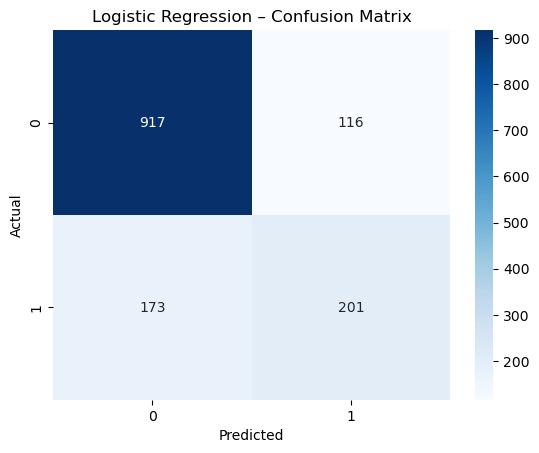

Evaluation_4; Recall: 0.5374331550802139


In [22]:
#Evaluation_1:Classification report (Accuracy, Precision, Recall, F1-score)

#Precision: When the model predicts churn, how often is it correct?
#Recall: Of all customers who actually churned, how many did we predict?
#F1-score: Avg between precision & recall.
#Support: Number of real samples in each class.

print("Evaluation_1;Classification report: ")
print(classification_report(y_test, y_pred_lr))
print("")


#Evaluation_2: ROC-AUC 

#ROC-AUC expects probability of the positive class (1)

print("Evaluation_2; ROC-AUC:", roc_auc_score(y_test, y_prob_lr))
print("")


#Evaluation_3: confusion_matrix 

cm = confusion_matrix(y_test, y_pred_lr)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

print("Evaluation_3;confusion_matrix report: ")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression – Confusion Matrix")
plt.show()

#Evaluation_4: Recall (Churn = 1) 

from sklearn.metrics import recall_score

print("Evaluation_4; Recall:" , recall_score(y_test, y_pred_lr))


##### Evaluation2: If you pick a churner and a non-churner randomly,there’s an 83.8% chance the model assigns a higher probability to the churner. That's very useful for prioritizing customers for retention campaigns.
##### When predicting churn, it's more important to find customers who will leave than to avoid calling customers who will stay. Losing a customer is expensive, but calling a loyal customer is cheap. 


##### Evaluation4: Approximately 53% of customers who actually churn. (Recall = TP / (TP + FN))

##### In churn prediction, missing a churner is much worse than contacting a loyal customer.
##### So, the model prioritizes recall for churners (class = 1) over avoiding false alarms.

### Phase 5-2: Advanced Model – Random Forest

In [23]:
#Advanced Model – Random Forest

from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=200,max_depth=10,random_state=42,class_weight='balanced')

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:,1]


C:\Users\intel\AppData\Local\Temp\ipykernel_17744\2003723148.py:7: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  rf.fit(X_train, y_train)


### Validation of Random Forest Model

Evaluation_1;Classification report _rf: 
              precision    recall  f1-score   support

           0       0.89      0.78      0.83      1033
           1       0.54      0.74      0.63       374

    accuracy                           0.77      1407
   macro avg       0.72      0.76      0.73      1407
weighted avg       0.80      0.77      0.78      1407


Evaluation_2; ROC-AUC_rf: 0.8362914205548451

Evaluation_3;confusion_matrix report_rf: 


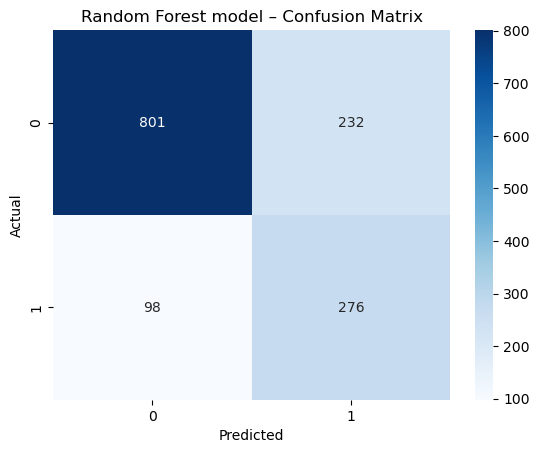

Evaluation_4; Recall: 0.7379679144385026


In [24]:
#Evaluation_1:Classification report

print("Evaluation_1;Classification report _rf: ")
print(classification_report(y_test, y_pred_rf))
print("")

#Evaluation_2: ROC-AUC

print("Evaluation_2; ROC-AUC_rf:", roc_auc_score(y_test, y_prob_rf))
print("") 

#Evaluation_3: confusion_matrix 

cm = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

print("Evaluation_3;confusion_matrix report_rf: ")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest model – Confusion Matrix")
plt.show()

#Evaluation_4: Recall (Churn = 1) 

print("Evaluation_4; Recall:" , recall_score(y_test, y_pred_rf))


### Comparison results for two models

In [25]:
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest'],
    'ROC_AUC': [roc_auc_score(y_test, y_prob_lr), roc_auc_score(y_test, y_prob_rf)],
    'Recall':[recall_score(y_test, y_pred_lr),recall_score(y_test, y_pred_rf) ] })

results


,Model,ROC_AUC,Recall
0,Logistic Regression,0.834568,0.537433
1,Random Forest,0.836291,0.737968


##### Saving the best Model 

In [26]:
import joblib

joblib.dump(rf,"C:/Users/intel/Documents/customer-churn-prediction/model/churn_model.pkl")


['C:/Users/intel/Documents/customer-churn-prediction/model/churn_model.pkl']

### churn probability per customer with RF model:

In [27]:
# churn probability per customer

churn_prob_df = X_test.copy()

churn_prob_df['Actual_Churn'] = y_test.values
churn_prob_df['Predicted_Churn_Probability'] = y_prob_rf
churn_prob_df['Preventive_Action_Call to client'] = (y_prob_rf >= 0.7).astype(int)

churn_prob_df.head()


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,Short_Tenure_Monthly,RevenuePotential,Actual_Churn,Predicted_Churn_Probability,Preventive_Action_Call to client
0,0,59,75.95,4542.35,0,1,1,1,0,0,...,1,1,1,0,0,0,4481.05,0,0.020321,0
1,0,7,78.55,522.95,0,0,0,1,0,1,...,0,1,0,0,0,1,549.85,0,0.807383,1
2,0,54,20.10,1079.45,0,0,0,1,0,0,...,1,0,0,0,1,0,1085.40,0,0.026653,0
3,0,2,20.65,38.70,0,0,0,1,0,0,...,0,0,0,0,1,1,41.30,1,0.157936,0
4,0,71,105.15,7555.00,0,1,0,1,0,1,...,1,1,0,0,0,0,7465.65,0,0.233937,0


##### Customers with predicted churn probability above 70% are classified as high risk and recommended for proactive retention actions.

### churn probability for data set

In [28]:
def churn_segment(p):
    if p >= 0.7:
        return "High Risk"
    elif p >= 0.4:
        return "Medium Risk"
    else:
        return "Low Risk"

churn_prob_df['Risk_Segment'] = churn_prob_df['Predicted_Churn_Probability'].apply(churn_segment)

churn_prob_df['Risk_Segment'].value_counts(normalize=True) * 100


Low Risk       56.218905
Medium Risk    25.302061
High Risk      18.479033
Name: Risk_Segment, dtype: float64